# 14 · Unified-memory flagship — a >16GB LLM on the Strix Halo iGPU

**Story arc.** Notebook **10**'s Group B pushed prover host RSS past a small host's limit *synthetically* (raising the r0vm
`segment_po2` until the real STARK prover's peak RSS exceeds 16 GB). This chapter makes the same point with
a **visceral, real workload**: a genuinely large instruct LLM — the RAG/agent **generator** — running
**fully offloaded on the Radeon 8060S iGPU** (`gfx1151`) via **llama.cpp built with HIP**, which a 16 GB
discrete GPU literally **cannot hold**.

> **Engine focus.** Radeon 8060S iGPU (`gfx1151`, llama.cpp **HIP/ROCm** backend) running
> **Qwen2.5-32B-Instruct Q4_K_M** (~20 GB) end-to-end on the 94 GB unified LPDDR5X.
>
> **Honesty rule (the spine of the lab).** This accelerates / enables the **AI MODEL** (the RAG
> generator), **not the proof** — the RISC0 zkRAG STARK stays **CPU-only** on AMD. The iGPU memory is part
> of the **94 GB unified pool** (a 32 GB VRAM carveout + GTT, both backed by LPDDR5X); the model does *not*
> use all 94 GB. The "16 GB cap" contrast below is **generous to a discrete card** — here the CPU spill is
> the *same* LPDDR5X, whereas a real 16 GB discrete GPU spills over PCIe or hard-OOMs.

In [1]:
import os

import labkit as lk

info = lk.capability_badge()   # read-only AMD probe — same badge as every lab notebook


def heavy_enabled():
    """Opt-in gate: only run the live 20GB iGPU bench when explicitly asked (LAB_RUN_HEAVY=1)."""
    return os.environ.get("LAB_RUN_HEAVY", "") == "1"


def model_present():
    """The live path needs the (gitignored) ~20GB GGUF actually on disk."""
    return lk.repo_path("poc", "amd-bigmodel-demo", "models",
                        "Qwen2.5-32B-Instruct-Q4_K_M.gguf").is_file()

✓,Zen5 CPU,AMD RYZEN AI MAX+ PRO 395 w/ Radeon 8060S · 32 threads · 94 GB unified
✓,Radeon iGPU (ROCm),gfx=gfx1151 · backend=rocm
—,Vulkan,not detected
✓,XDNA2 NPU,"enumerated (research; accelerates AI model, not proofs)"


## The credibility crux — how we honestly prove ">16 GB, a 16 GB discrete card OOMs"

Three honest pillars (no fabricated discrete-GPU number):

1. **Empirical** — we sample `rocm-smi --showmeminfo vram gtt` *during* the full-offload run and report
   **peak GPU-resident memory > 16 GB** (VRAM carveout + GTT, both GPU-addressable LPDDR5X).
2. **Footprint** — the model file + loaded size is **> 16 GB**, so a 16 GB discrete card cannot fully
   offload it.
3. **Contrast** — on the *same box* we cap GPU offload to a ~16 GB budget (`-ngl 32`) and show the
   **throughput cliff**, plus a CPU baseline (`-ngl 0`).

The figure below reads from the committed `bigmodel.{csv,json}`, so it renders on a laptop with **no GPU and
no 20 GB model** (replay). On the real Strix Halo with `LAB_RUN_HEAVY=1` it re-runs the live bench.

[REPLAY] unified-memory flagship — >16GB LLM on the iGPU (llama.cpp/HIP)  (LAB_FORCE_REPLAY set; using committed artefacts)
[REPLAY] source: poc/amd-bigmodel-demo/artefacts/bigmodel.csv (3 rows)


[REPLAY] source: poc/amd-bigmodel-demo/artefacts/bigmodel.json
[replay] Qwen2.5-32B-Instruct-Q4_K_M.gguf — weights 19.9 GB
[replay] full iGPU offload: peak GPU memory = 27.6 GB (VRAM 2.1 + GTT 25.5) -> exceeds 16 GB: True
[replay] throughput: prefill 287 tok/s · gen 10.1 tok/s


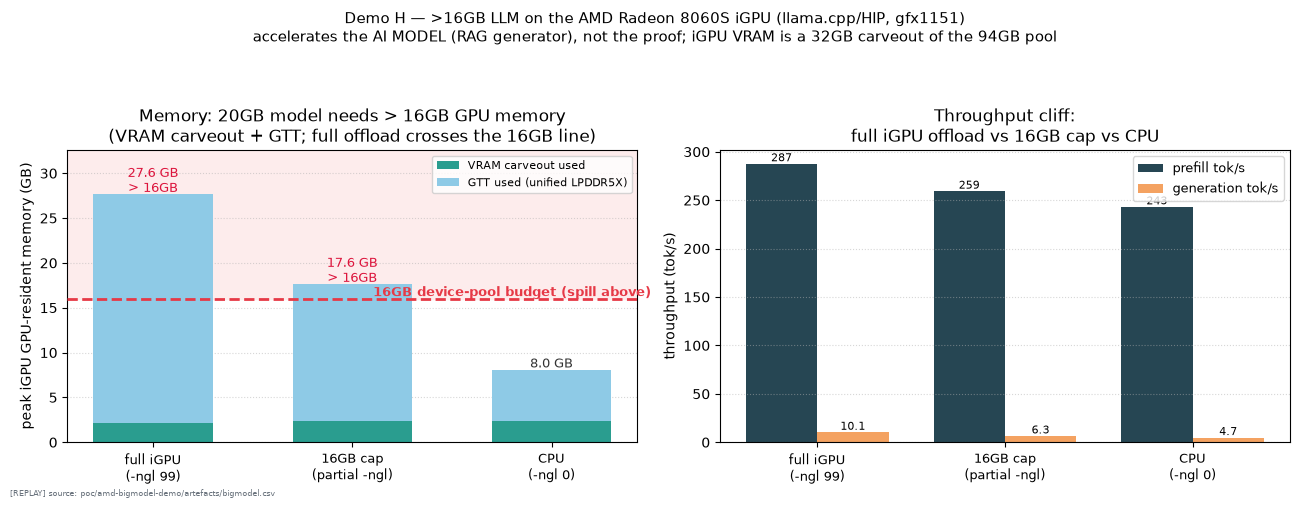

In [2]:
def live_bigmodel():   # heavy: build + fetch + run the 20GB iGPU bench. Gated off in lab-replay.
    import subprocess
    subprocess.run(["make", "demo-bigmodel"], cwd=str(lk.REPO_ROOT), check=True)
    return lk.load_bigmodel()


def replay_bigmodel():  # committed bigmodel.csv — the source of truth
    return lk.load_bigmodel()


df, mode = lk.live_or_replay(
    live_bigmodel, replay_bigmodel,
    requires=[heavy_enabled, lk.has_rocm, lk.is_strix_halo, model_present],
    label="unified-memory flagship — >16GB LLM on the iGPU (llama.cpp/HIP)")

fig = lk.plot_bigmodel_memory(df)

bm = lk.load_bigmodel_info()
full = bm["conditions"]["full_igpu"]
print(f"[{mode}] {bm['model']} — weights {bm['weights_gb']:.1f} GB")
print(f"[{mode}] full iGPU offload: peak GPU memory = {full['peak_gpu_gb']:.1f} GB "
      f"(VRAM {full['peak_vram_gb']:.1f} + GTT {full['peak_gtt_gb']:.1f}) "
      f"-> exceeds 16 GB: {bm['exceeds_16gb']}")
print(f"[{mode}] throughput: prefill {full['prefill_tps']:.0f} tok/s · gen {full['gen_tps']:.1f} tok/s")

### Honesty caveats (read once)

- **This accelerates the AI MODEL, not the proof.** The generator (the LLM that writes the RAG answer) runs
  on the iGPU; the RISC0 zkRAG STARK that *proves* retrieval stays **CPU-only** on AMD (notebooks 08/09).
- **iGPU memory is the unified pool, not a magic 94 GB of VRAM.** The model occupies a **32 GB VRAM carveout
  + GTT** slice of the 94 GB LPDDR5X — both GPU-addressable. It does **not** use all 94 GB; the large pool is
  what makes such a footprint *possible* vs a fixed 16 GB discrete board.
- **The 16 GB-cap contrast is generous to the discrete card.** Capping `-ngl` spills the rest to the Zen 5
  CPU over the *same LPDDR5X* — no PCIe penalty. A real 16 GB discrete GPU is **worse**: it spills over PCIe
  or hard-OOMs. The cliff shown is therefore a *lower bound* on the discrete-card pain.
- **Real pretrained weights.** Qwen2.5-32B-Instruct (not random-init) — the sample generation in
  `poc/amd-bigmodel-demo/artefacts/bigmodel.log` is genuine model output.

In [3]:
show = df[["condition", "ngl", "peak_gpu_gb", "prefill_tps", "gen_tps"]].copy()
cliff = None
try:
    g = df.set_index("condition")["gen_tps"]
    cliff = float(g.get("full_igpu")) / float(g.get("cap_16gb"))
except Exception:
    pass
print(show.to_string(index=False))
if cliff:
    print(f"\ngeneration throughput cliff (full iGPU / 16GB-cap) = {cliff:.1f}x")
print("\nfull GPU-resident footprint > 16 GB  =>  a 16 GB discrete GPU cannot fully hold this model.")

condition  ngl  peak_gpu_gb  prefill_tps  gen_tps
full_igpu   99        27.62       287.44    10.12
 cap_16gb   32        17.59       259.15     6.30
      cpu    0         8.04       242.91     4.70

generation throughput cliff (full iGPU / 16GB-cap) = 1.6x

full GPU-resident footprint > 16 GB  =>  a 16 GB discrete GPU cannot fully hold this model.


## What this shows about AMD (hardware + software)

- **Hardware.** The 94 GB unified LPDDR5X lets the `gfx1151` iGPU hold a **>16 GB** model (VRAM carveout +
  GTT) and run it end-to-end — a footprint a 16 GB discrete board simply cannot fit in its VRAM. This is the
  *real-workload* face of notebook 10's synthetic `segment_po2` mem-wall: the same memory wall, but a model you
  can actually talk to.
- **Software.** **llama.cpp built with HIP/ROCm** (`-DGGML_HIP=ON -DAMDGPU_TARGETS=gfx1151`) puts the whole
  transformer on the AMD iGPU — no CUDA, no discrete card. The weights map primarily into the unified-pool
  **GTT** region; the runtime treats it as GPU memory.
- **The honest boundary holds.** This is the **AI model / generator** accelerated by the iGPU. The
  **proof** (RISC0 zkRAG STARK) is unchanged — still CPU-only on AMD.

**Sources.** [`poc/amd-bigmodel-demo/`](../poc/amd-bigmodel-demo/README.md) ·
committed evidence `poc/amd-bigmodel-demo/artefacts/bigmodel.{csv,json,log,png}` ·
[`docs/amd-strix-halo-advantage.md`](https://github.com/iiyyll01lin/zkp-final/blob/main/docs/amd-strix-halo-advantage.md) (robust-win #2) ·
[`docs/amd-strix-halo-acceleration.md`](https://github.com/iiyyll01lin/zkp-final/blob/main/docs/amd-strix-halo-acceleration.md).

## Zero-copy — *why* the >16 GB model is also fast (no PCIe copy)

The headline above is "it *fits*". The companion point is "it is also *fast to feed*". On a discrete GPU the
weights and KV-cache must cross **PCIe** from host RAM into VRAM via an explicit staging copy. On this APU
there is **no PCIe** — the CPU and `gfx1151` iGPU share one **LPDDR5X** pool — so the model's memory is
reachable by the iGPU **without** a staging copy. That is the same unified-memory property the dedicated
microbench in [`21_unified_memory_deepdive.ipynb`](https://github.com/iiyyll01lin/zkp-final/blob/main/lab/21_unified_memory_deepdive.ipynb) measures directly:
`hipHostMalloc` (zero-copy) and `hipMallocManaged` (page-migrated, warm) reach essentially the same
bandwidth as a device-resident `hipMalloc` buffer, because the "copy" the discrete card is forced to pay
simply does not exist here.

The cell below pulls that committed microbench (if present) so the bigmodel "it fits" story and the
"no-PCIe-copy" bandwidth story sit on the same page.

In [4]:
# The zero-copy bandwidth evidence (committed microbench from notebook 21 / poc/amd-unified-memory-demo).
try:
    uma = lk.load_uma_bandwidth()
    g = uma.set_index(["alloc_kind", "op"])["gbytes_s"]
    dev_resident = float(g.get(("hipMalloc", "kernel_saxpy")))
    zero_copy = float(g.get(("hipHostMalloc", "kernel_saxpy")))
    print("APU unified-memory SAXPY bandwidth (no PCIe — one LPDDR5X pool):")
    print(uma[["alloc_kind", "op", "gbytes_s", "note"]].to_string(index=False))
    print(f"\nzero-copy / device-resident = {zero_copy/dev_resident*100:.0f}% "
          f"({zero_copy:.0f} vs {dev_resident:.0f} GB/s) -> the staging copy a discrete card pays is absent here.")
except Exception as exc:
    print(f"(unified-memory microbench not available: {exc}; run `make demo-uma` or see notebook 21)")

[REPLAY] source: poc/amd-unified-memory-demo/artefacts/uma-bandwidth.csv (6 rows)
APU unified-memory SAXPY bandwidth (no PCIe — one LPDDR5X pool):
      alloc_kind                op  gbytes_s                  note
       hipMalloc        memcpy_h2d     74.97 explicit-staging-copy
       hipMalloc      kernel_saxpy    217.80       device-resident
       hipMalloc        memcpy_d2h     63.29 explicit-staging-copy
   hipHostMalloc      kernel_saxpy    209.35  zero-copy-no-staging
hipMallocManaged kernel_saxpy_cold    123.94   first-touch-migrate
hipMallocManaged kernel_saxpy_warm    212.57        pages-resident

zero-copy / device-resident = 96% (209 vs 218 GB/s) -> the staging copy a discrete card pays is absent here.


## Appendix (gated) — beyond 16 GB: *measured* >32 GB

Two boxes, two machines — both the `gfx1151` Radeon 8060S, but different unified-memory configs:

- **Box 1 — Z2 (this presentation box) · Llama-3.3-70B-Instruct Q4_K_M.** Peak GPU-resident **44.77 GB**
  (VRAM carveout + GTT, `rocm-smi` sampled) at full offload — **> 32 GB**, i.e. the resident working set
  exceeds a *32 GB* card's VRAM (what that costs such a card over PCIe is not measured here).
  **Reproducible right here** on the Z2 (`bigmodel-xl.csv`).
- **Box 2 — Halo B (a different 128 GB / 96 GB-carveout Strix Halo) · Gemma-3-27B-it BF16.** Peak
  GPU-resident **56.13 GB** at full offload — **> 32 GB**. Measured on **Halo B**, *not* the Z2: the
  presenter Z2's ROCr compute pool caps at ~47 GiB and cannot hold a 54 GB BF16 model, so this box is
  explicitly labeled as the larger-config machine (`bigmodel-xl-gemma-bf16.csv`; 2 rows, **no CPU
  baseline** — an `-ngl 0` run on the 96 GB carveout measures NVMe thrash, not CPU compute).

The cell below reads the committed `bigmodel-xl*.csv` (**replay-only** — no GPU, no `.gguf` on disk) and
computes the ">32 GB" call **directly from the measured `peak_gpu_gb`**, not from any precomputed JSON flag.

Appendix (gated) - beyond 16GB: MEASURED >32GB, PENDING AMD BENCHMARK SIGN-OFF
[REPLAY] source: poc/amd-bigmodel-demo/artefacts/bigmodel-xl.csv (3 rows)
[Z2 (this box)] Llama-3.3-70B-Instruct Q4_K_M peak GPU-resident = 44.77 GB  ->  > 32GB: True
                reproducible here on the Z2
[REPLAY] source: poc/amd-bigmodel-demo/artefacts/bigmodel-xl-gemma-bf16.csv (2 rows)


[Halo B       ] Gemma-3-27B-it BF16           peak GPU-resident = 56.13 GB  ->  > 32GB: True
                on Halo B (128GB/96GB-carveout Strix Halo); presenter Z2's ROCr pool caps ~47GiB
----------------------------------------------------------------------------------
VERDICT (gated): both models exceed a 32GB discrete card's VRAM, measured on AMD gfx1151 iGPUs:
  - Z2 (this box) Llama-3.3-70B-Instruct Q4_K_M 44.77 GB  > 32 = True
  - Halo B        Gemma-3-27B-it BF16           56.13 GB  > 32 = True
Still PENDING AMD benchmark sign-off  ->  the PUBLIC HEADLINE stays the gated 16-24GB (>16GB) claim;
this appendix does NOT flip the chapter title/narrative. It accelerates the AI MODEL, not the proof.


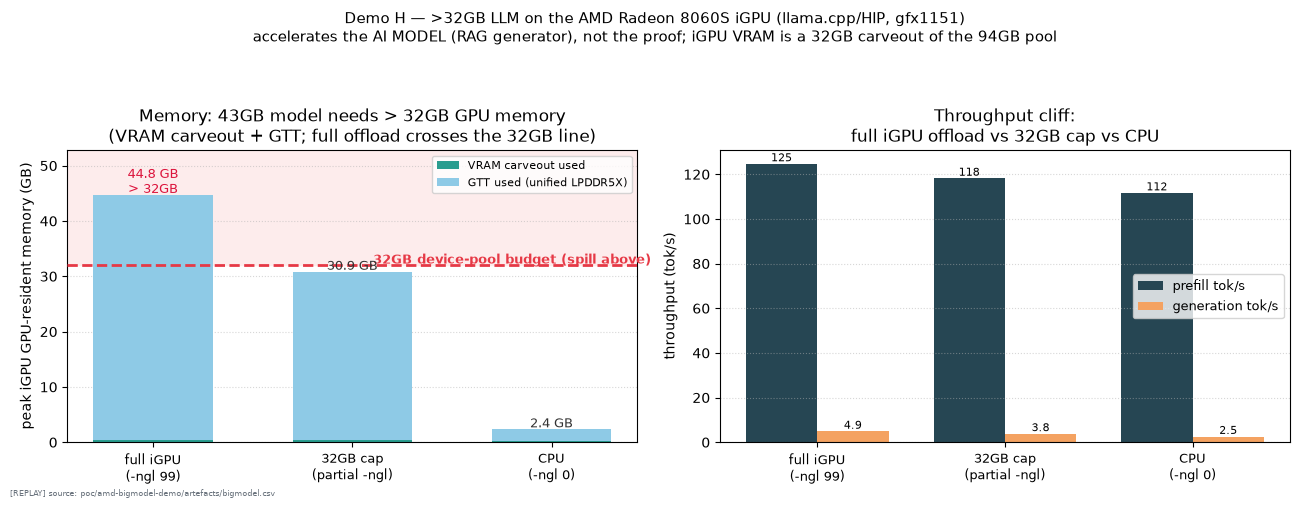

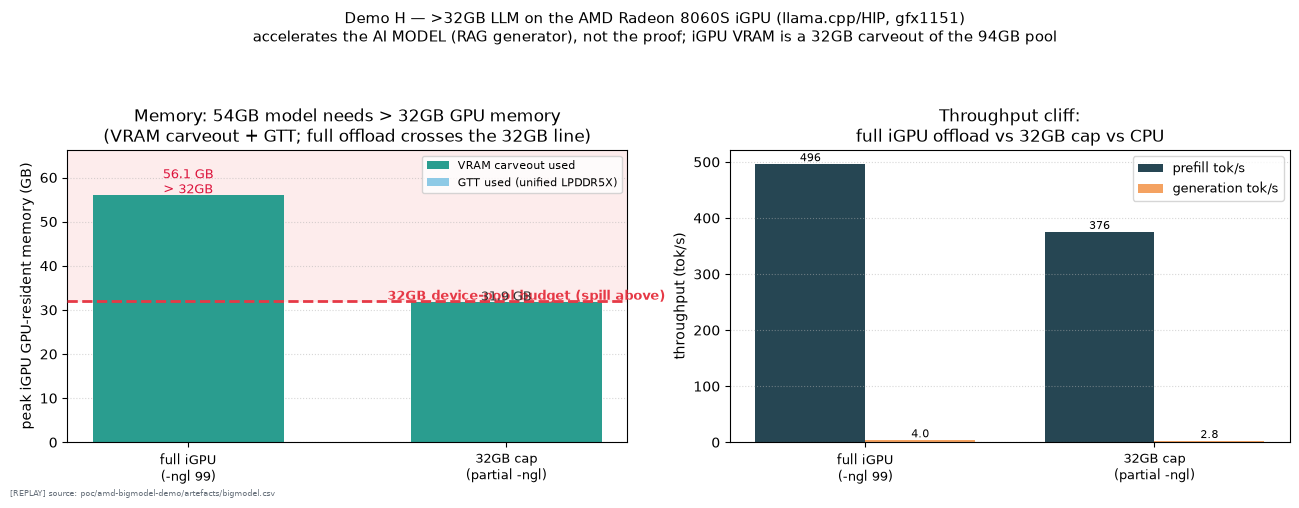

In [5]:
# Appendix (gated) — the SAME unified-memory story, pushed past a 32GB discrete card.
# Replay-only: reads the committed bigmodel-xl*.csv (no GPU, no .gguf on disk). The
# ">32GB" verdict is computed DIRECTLY from the measured peak_gpu_gb, not any JSON flag.
DISCRETE_32 = 32.0

appendix_runs = [
    ("bigmodel-xl.csv",            "Z2 (this box)", "Llama-3.3-70B-Instruct Q4_K_M",
     "reproducible here on the Z2"),
    ("bigmodel-xl-gemma-bf16.csv", "Halo B",        "Gemma-3-27B-it BF16",
     "on Halo B (128GB/96GB-carveout Strix Halo); presenter Z2's ROCr pool caps ~47GiB"),
]

print("Appendix (gated) - beyond 16GB: MEASURED >32GB, PENDING AMD BENCHMARK SIGN-OFF")
print("=" * 82)
measured = []
for csv_name, host, model, note in appendix_runs:
    df_xl = lk.load_bigmodel(lk.repo_path("poc", "amd-bigmodel-demo", "artefacts", csv_name))
    peak = float(df_xl.set_index("condition").loc["full_igpu", "peak_gpu_gb"])  # measured (CSV)
    exceeds_32 = peak > DISCRETE_32                                             # verdict from data
    measured.append((host, model, peak, exceeds_32))
    lk.plot_bigmodel_memory(df_xl, discrete_gb=DISCRETE_32, cap_key="cap_32gb")
    print(f"[{host:13}] {model:29} peak GPU-resident = {peak:5.2f} GB  ->  > 32GB: {exceeds_32}")
    print(f"                {note}")

print("-" * 82)
print("VERDICT (gated): both models exceed a 32GB discrete card's VRAM, measured on AMD gfx1151 iGPUs:")
for host, model, peak, exceeds_32 in measured:
    print(f"  - {host:13} {model:29} {peak:5.2f} GB  > 32 = {exceeds_32}")
print("Still PENDING AMD benchmark sign-off  ->  the PUBLIC HEADLINE stays the gated 16-24GB (>16GB) claim;")
print("this appendix does NOT flip the chapter title/narrative. It accelerates the AI MODEL, not the proof.")